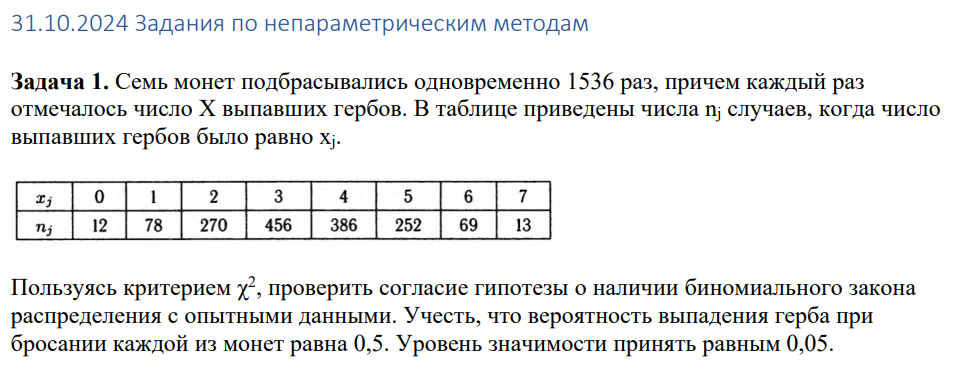

In [ ]:
import numpy as np
from scipy.stats import binom, chisquare, binomtest
trials = 1536  # кол-во подбрасываний
r = 7  # число монет
p = 0.5  # вероятность выпадения герба

# число выпадений xj
m = np.array([12, 78, 270, 456, 386, 252, 69, 13])
m_expected = np.array([binom.pmf(k, r, p) * trials for k in range(r + 1)])

#  критерий χ²
x2stat, p_value = chisquare(m, m_expected)
alpha = 0.05
print(f'Статистика χ²: {x2stat}')
print(f'p-значение: {p_value}')
if p_value < alpha:
    print('Отклоняем нулевую гипотезу. Распределение не соответствует биномиальному.')
else:
    print('Не отклоняем нулевую гипотезу. Распределение соответствует биномиальному.')

Статистика χ²: 10.314285714285688
p-значение: 0.1714516975623399
Не отклоняем нулевую гипотезу. Распределение соответствует биномиальному.


# **Задача 2.**

С помощью критерия знаков проверьте гипотезу о том, что две следующие
выборки однородны:
0,20 1,72 0,27 0,88 1,51 0,68 1,86 0,59 1,12 0,30
и
0,89 0,04 0,75 0,88 0,24 0,03 0,47 0,60 0,37 0,77

Гипотезы:

Ho - выборки однородны (медианы равны)

H1 - выборки неоднородны (медианы не равны)


In [ ]:
import numpy as np
from scipy import stats

In [ ]:
sample_1 = np.array([0.20, 1.72, 0.27, 0.88, 1.51, 0.68, 1.86, 0.59, 1.12, 0.30])
sample_2 = np.array([0.89, 0.04, 0.75, 0.88, 0.24, 0.03, 0.47, 0.60, 0.37, 0.77])

# Разность между выборками
differences = sample_1 - sample_2
non_zero_differ = differences[differences != 0] # убираю нулевые разности

# Количество положительных и отрицательных знаков
pos_count = np.sum(non_zero_differ > 0)
neg_count = np.sum(non_zero_differ < 0)
n = len(non_zero_differ)
t = min(pos_count, neg_count)

# Уровень значимости
alpha = 0.05

# критическое значение
critical_value = stats.binom.ppf(1 - alpha, n, 0.5)

# Вычисляем p-value (двусторонний тест)
p_value = stats.binom.cdf(t, n, 0.5) * 2  # умножаю на 2 для двустороннего теста

# Проверяем гипотезу
if t <= critical_value:
  print("Нулевая гипотеза о том, что выборки однородны, не отвергается.")
else:
  print("Нулевая гипотеза о том, что выборки однородны, отвергается.")

print(f"Количество положительных знаков: {pos_count}")
print(f"Количество отрицательных знаков: {neg_count}")
print(f"Статистика знаков T: {t}")
print(f"P-value: {p_value}")

Нулевая гипотеза о том, что выборки однородны, не отвергается.
Количество положительных знаков: 5
Количество отрицательных знаков: 4
Статистика знаков T: 4
P-value: 1.0


# **Задача 3.**
Рассмотрим последовательность из 25 испытаний. Пусть результаты этих
испытаний следующие (1 пишется в случае успеха и 0 в случае неудачи):
1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1
С помощью критерия знаков проверьте гипотезу о том, что вероятность успеха равна 0.5

In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import binom, binomtest
# Дано:
# последовательность успехов и неудач 25 испытаний
data = [1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

# посчитаем количество успехов
successes = sum(data)
n = len(data)

# критерий биномиального теста
test_result = binomtest(successes, n=n, p=0.5)

alpha = 0.05
print(f'Количество успехов: {successes} из {n}')
print(f'p-значение: {test_result.pvalue}')

if test_result.pvalue < alpha:
    print('Отклоняем нулевую гипотезу. Вероятность успеха не равна 0.5.')
else:
    print('Не отклоняем нулевую гипотезу. Вероятность успеха равна 0.5.')

Количество успехов: 19 из 25
p-значение: 0.01463329792022705
Отклоняем нулевую гипотезу. Вероятность успеха не равна 0.5.


# **Задача 4.**
 Цена за квадратный метр в объявлениях о продаже квартир в городе равна:
0,85 0,96 0,95 0,03 0,33 0,63 0,12,
а в поселке-спутнике – равна:
0,51 0,63 0,76
С помощью критерия Манна-Уитни проверьте гипотезу о том, что цены на жильё в
городе и поселке-спутнике одинаковы.


In [ ]:
import numpy as np
from scipy.stats import mannwhitneyu
# Цены за квадратный метр
city_prices = np.array([0.85, 0.96, 0.95, 0.03, 0.33, 0.63, 0.12])
village_prices = np.array([0.51, 0.63, 0.76])
# Критерий Манни-Уитни
statistic, p_value = mannwhitneyu(city_prices, village_prices, alternative='two-sided')
print(f'U-статистика: {statistic}')
print(f'P-value: {p_value}')

alpha = 0.05
if p_value < alpha:
  print('Отвергаем нулевую гипотезу: цены на жилье в городе и поселке-спутнике различаются.')
else:
  print('Не отвергаем нулевую гипотезу: нет достаточных оснований считать, что цены различаются.')

U-статистика: 10.5
P-value: 1.0
Не отвергаем нулевую гипотезу: нет достаточных оснований считать, что цены различаются.


# **Задача 5.**

 Доля замужних женщин на трех предприятиях составляет:
0.52, 0.42, 0.31,
а в 10 офисах:
0.28, 0.94, 0.71, 0.00, 0.21, 0.07, 0.66
С помощью критерия Уилкоксона проверьте гипотезу о том, что число замужних женщин
имеет распределение, не зависящее от места работы.

In [ ]:
import numpy as np
from scipy.stats import ranksums

# Доля замужних женщин на предприятиях и в офисах
enterprise_married = np.array([0.52, 0.42, 0.31])
office_married = np.array([0.28, 0.94, 0.71, 0.00, 0.21, 0.07, 0.66])

# критерий Уилкоксона
stat, p_value = ranksums(enterprise_married, office_married)

# уровень значимости
alpha = 0.05

# результат
print(f'критерий ранговых сумм: {stat}')
print(f'p-значение: {p_value}')

if p_value < alpha:
  print('Отвергаем нулевую гипотезу: число замужних женщин зависит от места работы.')
else:
  print('Не отвергаем нулевую гипотезу: нет достаточных оснований считать, что число замужних женщин зависит от места работы.')

критерий ранговых сумм: 0.3418817293789138
p-значение: 0.7324398999038725
Не отвергаем нулевую гипотезу: нет достаточных оснований считать, что число замужних женщин зависит от места работы.


# **Задача 6.**

Даны выборочные наблюдения за двумя случайными величинами:
X: 5, 0, 3, 5, 1;
Y: 4, 0, 7, 5, 3, 8, 6.
С помощью критерия Уилкоксона (используя нормальную аппроксимацию и таблицу
стандартного нормального распределения) проверьте нулевую гипотезу о равенстве
распределений выборок X и Y для 94% уровня доверия против двусторонних альтернатив.

In [ ]:
import numpy as np
from scipy.stats import ranksums
# Дано
x = [5, 0, 3, 5, 1]
y = [4, 0, 7, 5, 3, 8, 6]

# Решение

# Критерий Уилкоксона
stat, p_value = ranksums(x, y)
# alpha = 1 - 0.94 - для уровня доверия 94%
alpha = 0.06

# Вывод результата
print(f'критерий ранговых сумм: {stat}')
print(f'p-значение: {p_value}')

if p_value < alpha:
    print('Отвергаем Ho (нулевую гипотезу). Распределения выборок различаются.')
else:
    print('Не отвергаем Ho (нулевую гипотезу). Распределения выборок одинаковы.')

критерий ранговых сумм: -1.2179969144117253
p-значение: 0.22322514530675575
Не отвергаем Ho (нулевую гипотезу). Распределения выборок одинаковы.
